# ***Supervised Models***

In [1]:
# Library
import os
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Preprocessing**

In [2]:
# Download the Breast cancer dataset from Kaggle
dataset_path = kagglehub.dataset_download('uciml/breast-cancer-wisconsin-data')

# construct the full path to the adult11.csv file.
file_path = os.path.join(dataset_path, 'data.csv')

# Load the dataset using pandas
bcwd = pd.read_csv(file_path)
bcwd

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
# check missing value
bcwd.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [4]:
# dropp unnecessary column Unnamed: 32 & id
bcwd.drop('id', axis=1, inplace=True)
bcwd.drop('Unnamed: 32', axis=1, inplace=True)
bcwd

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
bcwd['diagnosis'].value_counts() # print diagnosis values

,count
diagnosis,
B,357
M,212


In [6]:
# Encode diagnosis (label encoding)
bcwd['diagnosis'] = bcwd['diagnosis'].map({'M': 1, 'B': 0})
x_bcwd = bcwd.drop('diagnosis', axis=1) #Separate features (X) and target (y)
y_bcwd = bcwd['diagnosis']
bcwd

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
# (( Split the data into training and testing sets "70% train, 30% test" ))

X_bcwd_train, X_bcwd_test, y_bcwd_train, y_bcwd_test = train_test_split(x_bcwd, y_bcwd, test_size=0.3, random_state=42)

X_bcwd_train ,y_bcwd_train

(     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
 149       13.740         17.91           88.12      585.0          0.07944   
 124       13.370         16.39           86.10      553.5          0.07115   
 421       14.690         13.98           98.22      656.1          0.10310   
 195       12.910         16.33           82.53      516.4          0.07941   
 545       13.620         23.23           87.19      573.2          0.09246   
 ..           ...           ...             ...        ...              ...   
 71         8.888         14.64           58.79      244.0          0.09783   
 106       11.640         18.33           75.17      412.5          0.11420   
 270       14.290         16.82           90.30      632.6          0.06429   
 435       13.980         19.62           91.12      599.5          0.10600   
 102       12.180         20.52           77.22      458.7          0.08013   
 
      compactness_mean  concavity_mean  concave po

In [8]:
# Standardize numerical features
scaler = StandardScaler()
X_bcwd_train_scaled = scaler.fit_transform(X_bcwd_train)
X_bcwd_test_scaled = scaler.transform(X_bcwd_test)

# **Model Building & Evaluation then Visualization**

> **Logistic Regression model**

In [9]:
# Logistic Regression model
LR_model = LogisticRegression(max_iter=2500)

# Train the model
LR_model.fit(X_bcwd_train_scaled, y_bcwd_train)

LogisticRegression(max_iter=2500)

In [10]:
# # Making predictions on the test set
y_pred = LR_model.predict(X_bcwd_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_pred)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [11]:
# Compute metrics Logistic Regression on BCWD dataset
LR_accuracy = accuracy_score(y_bcwd_test, y_pred) # accuracy

LR_precision = precision_score(y_bcwd_test, y_pred) # precision

LR_recall = recall_score(y_bcwd_test, y_pred) # recall

LR_f1 = f1_score(y_bcwd_test, y_pred) # f1

LR_roc_auc = roc_auc_score(y_bcwd_test, LR_model.predict_proba(X_bcwd_test_scaled)[:, 1]) # ROC-AUC Score

print("Logistic Regression Evaluation on BCWD Data:")
print(f"Accuracy: {LR_accuracy:.4f}")
print(f"Precision: {LR_precision:.4f}")
print(f"Recall: {LR_recall:.4f}")
print(f"F1-Score: {LR_f1:.4f}")
print(f"ROC-AUC Score: {LR_roc_auc:.4f}")

Logistic Regression Evaluation on BCWD Data:
Accuracy: 0.9825
Precision: 0.9688
Recall: 0.9841
F1-Score: 0.9764
ROC-AUC Score: 0.9979


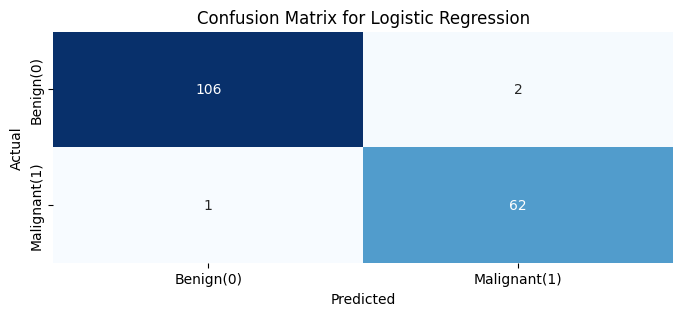

In [12]:
# confusion matrices for LR
LR_cm = confusion_matrix(y_bcwd_test, y_pred)
plt.figure(figsize=(8, 3))
sns.heatmap(LR_cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Benign(0)', 'Malignant(1)'], yticklabels=['Benign(0)', 'Malignant(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()



---



> **Naive Bayes model**

In [13]:
# Train a Naive Bayes model ((Gaussian))
nb_model = GaussianNB()

nb_model.fit(X_bcwd_train_scaled, y_bcwd_train)

GaussianNB()

In [14]:
# Making predictions on the test set
b_y_pred = nb_model.predict(X_bcwd_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_pred)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [15]:
# Compute metrics Naive Bayes
nb_y_pred = nb_model.predict(X_bcwd_test_scaled)

nb_accuracy = accuracy_score(y_bcwd_test, nb_y_pred) # accuracy

nb_precision = precision_score(y_bcwd_test, nb_y_pred) # precision

nb_recall = recall_score(y_bcwd_test, nb_y_pred) # recall

nb_f1 = f1_score(y_bcwd_test, nb_y_pred) # f1

nb_roc_auc = roc_auc_score(y_bcwd_test, nb_model.predict_proba(X_bcwd_test_scaled)[:, 1]) # ROC-AUC Score

print("\nNaive Bayes Evaluation on BCWD Data:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print(f"ROC-AUC Score: {nb_roc_auc:.4f}")


Naive Bayes Evaluation on BCWD Data:
Accuracy: 0.9357
Precision: 0.9194
Recall: 0.9048
F1-Score: 0.9120
ROC-AUC Score: 0.9927


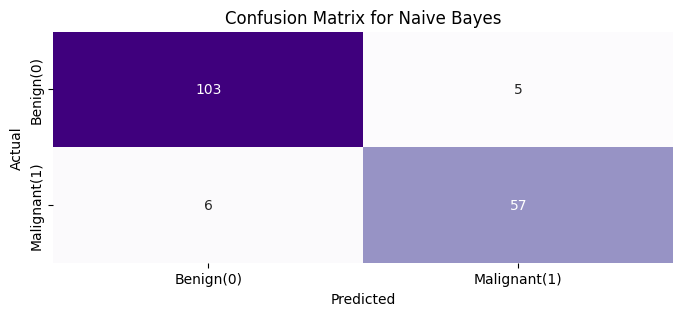

In [16]:
# confusion matrices for NB
nb_cm = confusion_matrix(y_bcwd_test, nb_y_pred)
plt.figure(figsize=(8, 3))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Purples', cbar=False, xticklabels=['Benign(0)', 'Malignant(1)'], yticklabels=['Benign(0)', 'Malignant(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()



---



> **Bernouli**

In [17]:
# Bernoulli Naive Bayes
ber_model = BernoulliNB()
ber_model.fit(X_bcwd_train_scaled, y_bcwd_train)

BernoulliNB()

In [18]:
# Making predictions on the test set
ber_y_pred = ber_model.predict(X_bcwd_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_pred)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [19]:
# Compute metrics Bernoulli
ber_y_pred = ber_model.predict(X_bcwd_test_scaled)

ber_accuracy = accuracy_score(y_bcwd_test, ber_y_pred) # accuracy

ber_precision = precision_score(y_bcwd_test, ber_y_pred) # precision

ber_recall = recall_score(y_bcwd_test, ber_y_pred) # recall

ber_f1 = f1_score(y_bcwd_test, ber_y_pred) # f1

ber_roc_auc = roc_auc_score(y_bcwd_test, ber_model.predict_proba(X_bcwd_test_scaled)[:, 1]) # ROC-AUC Score

print("\nBernoulli Naive Bayes Evaluation on BCWD Data:")
print(f"Accuracy: {ber_accuracy:.4f}")
print(f"Precision: {ber_precision:.4f}")
print(f"Recall: {ber_recall:.4f}")
print(f"F1-Score: {ber_f1:.4f}")
print(f"ROC-AUC Score: {ber_roc_auc:.4f}")


Bernoulli Naive Bayes Evaluation on BCWD Data:
Accuracy: 0.9649
Precision: 0.9524
Recall: 0.9524
F1-Score: 0.9524
ROC-AUC Score: 0.9968


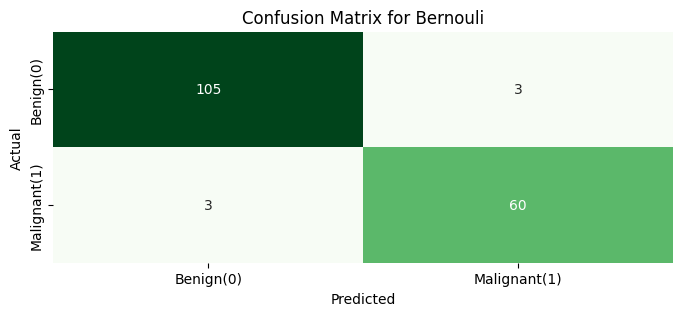

In [20]:
# confusion matrices for Bernouli
ber_cm = confusion_matrix(y_bcwd_test, ber_y_pred)
plt.figure(figsize=(8, 3))
sns.heatmap(ber_cm, annot=True, fmt='d', cmap='Greens', cbar=False, xticklabels=['Benign(0)', 'Malignant(1)'], yticklabels=['Benign(0)', 'Malignant(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Bernouli')
plt.show()



---



> ***Support Vector Machine model***

In [21]:
# SVM model
svm_model = SVC(probability=True)

# Train the model
svm_model.fit(X_bcwd_train_scaled, y_bcwd_train)

SVC(probability=True)

In [22]:
# # Making predictions on the test set
y_pred = svm_model.predict(X_bcwd_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_pred)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [23]:
# Compute metrics SVM
svm_y_pred = svm_model.predict(X_bcwd_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_pred)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


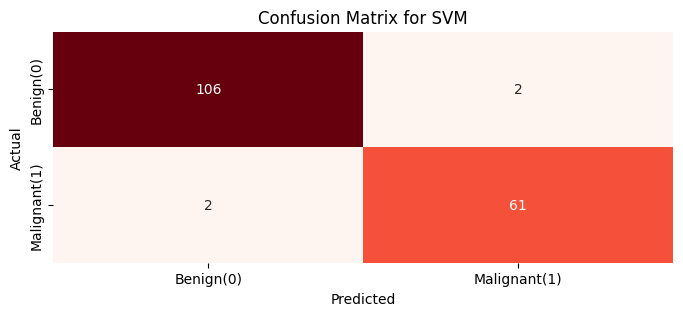

In [24]:
# confusion matrices for SVM
svm_cm = confusion_matrix(y_bcwd_test, svm_y_pred)
plt.figure(figsize=(8, 3))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Reds', cbar=False, xticklabels=['Benign(0)', 'Malignant(1)'], yticklabels=['Benign(0)', 'Malignant(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM')
plt.show()



---



# **Model Performance Comparison**

In [25]:
# Get the predicted probabilities for the positive class for each model
y_prob_LR = LR_model.predict_proba(X_bcwd_test_scaled)[:, 1]
y_prob_nb = nb_model.predict_proba(X_bcwd_test_scaled)[:, 1]
y_prob_ber = ber_model.predict_proba(X_bcwd_test_scaled)[:, 1]
y_prob_svm = svm_model.predict_proba(X_bcwd_test_scaled)[:, 1]

# Calculate the False Positive Rate, True Positive Rate, and thresholds
fpr_log, tpr_log, _ = roc_curve(y_bcwd_test, y_prob_LR)
fpr_gnb, tpr_gnb, _ = roc_curve(y_bcwd_test, y_prob_nb)
fpr_bnb, tpr_bnb, _ = roc_curve(y_bcwd_test, y_prob_ber)
fpr_svm, tpr_svm, _ = roc_curve(y_bcwd_test, y_prob_svm)

# Calculate the Area Under the ROC Curve (AUC)
auc_log = roc_auc_score(y_bcwd_test, y_prob_LR)
auc_gnb = roc_auc_score(y_bcwd_test, y_prob_nb)
auc_bnb = roc_auc_score(y_bcwd_test, y_prob_ber)
auc_svm = roc_auc_score(y_bcwd_test, y_prob_svm)

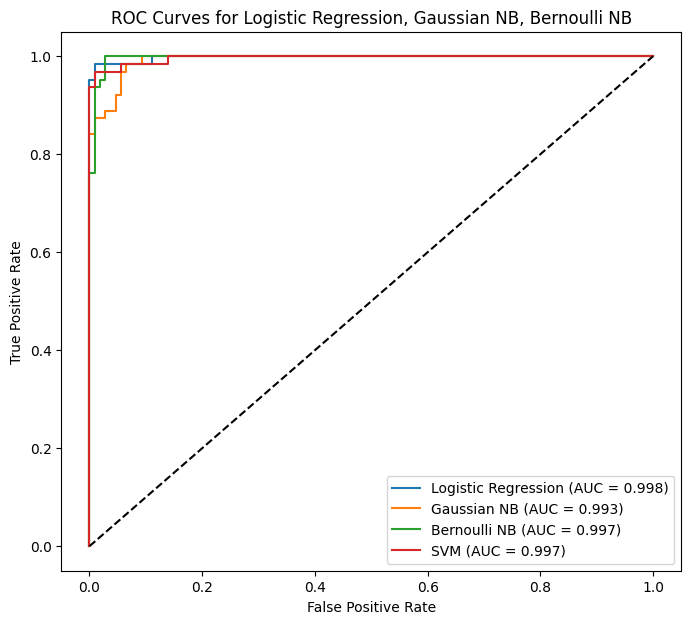

In [26]:
  # plot the carve
plt.figure(figsize=(8, 7))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_gnb, tpr_gnb, label=f"Gaussian NB (AUC = {auc_gnb:.3f})")
plt.plot(fpr_bnb, tpr_bnb, label=f"Bernoulli NB (AUC = {auc_bnb:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression, Gaussian NB, Bernoulli NB")
plt.legend(loc="lower right")
plt.show()

In [27]:
y_pred_LR = LR_model.predict(X_bcwd_test_scaled)
y_pred_nb = nb_model.predict(X_bcwd_test_scaled)
y_pred_ber = ber_model.predict(X_bcwd_test_scaled)
y_pred_svm = svm_model.predict(X_bcwd_test_scaled)

test_accuracies_LR = accuracy_score(y_bcwd_test, y_pred_LR)
test_accuracies_nb = accuracy_score(y_bcwd_test, y_pred_nb)
test_accuracies_ber = accuracy_score(y_bcwd_test, y_pred_ber)
test_accuracies_svm = accuracy_score(y_bcwd_test, y_pred_svm)

test_precisions_LR = precision_score(y_bcwd_test, y_pred_LR)
test_precisions_nb = precision_score(y_bcwd_test, y_pred_nb)
test_precisions_ber = precision_score(y_bcwd_test, y_pred_ber)
test_precisions_svm = precision_score(y_bcwd_test, y_pred_svm)

test_recalls_LR = recall_score(y_bcwd_test, y_pred_LR)
test_recalls_nb = recall_score(y_bcwd_test, y_pred_nb)
test_recalls_ber = recall_score(y_bcwd_test, y_pred_ber)
test_recalls_svm = recall_score(y_bcwd_test, y_pred_svm)

test_f1_scores_LR = f1_score(y_bcwd_test, y_pred_LR)
test_f1_scores_nb = f1_score(y_bcwd_test, y_pred_nb)
test_f1_scores_ber = f1_score(y_bcwd_test, y_pred_ber)
test_f1_scores_svm = f1_score(y_bcwd_test, y_pred_svm)

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [test_accuracies_LR, test_precisions_LR, test_recalls_LR, test_f1_scores_LR],
    'Naive Bayes': [test_accuracies_nb, test_precisions_nb, test_recalls_nb, test_f1_scores_nb],
    'Bernoulli Naive Bayes': [test_accuracies_ber, test_precisions_ber, test_recalls_ber, test_f1_scores_ber],
    'SVM': [test_accuracies_svm, test_precisions_svm, test_recalls_svm, test_f1_scores_svm]
}

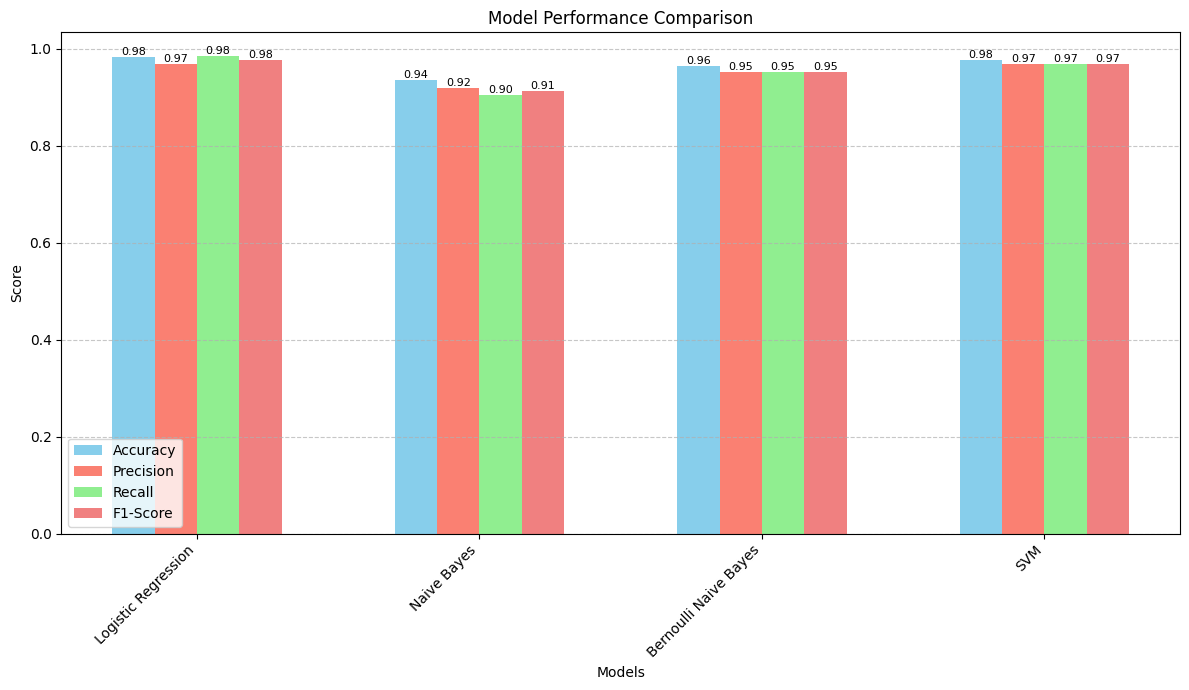

In [28]:
fig, ax = plt.subplots(figsize=(12, 7))

models = ['Logistic Regression', 'Naive Bayes', 'Bernoulli Naive Bayes', 'SVM']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Data extraction for each metric across all models
accuracies = [comparison_data[model][0] for model in models]
precisions = [comparison_data[model][1] for model in models]
recalls = [comparison_data[model][2] for model in models]
f1_scores = [comparison_data[model][3] for model in models]

num_models = len(models)

# X-axis positions for each group of bars (each model)
x = np.arange(num_models)

# Bar width and positions
bar_width = 0.15

# Plotting bars for each metric
bar1 = ax.bar(x - 1.5*bar_width, accuracies, bar_width, label='Accuracy', color='skyblue')
bar2 = ax.bar(x - 0.5*bar_width, precisions, bar_width, label='Precision', color='salmon')
bar3 = ax.bar(x + 0.5*bar_width, recalls, bar_width, label='Recall', color='lightgreen')
bar4 = ax.bar(x + 1.5*bar_width, f1_scores, bar_width, label='F1-Score', color='lightcoral')

# Add text labels
for container in [bar1, bar2, bar3, bar4]:
    for bar_patch in container:
        height = bar_patch.get_height()
        ax.text(bar_patch.get_x() + bar_patch.get_width() / 2, height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()